In [1]:
import numpy as np
import pandas as pd
import sklearn

import torch
import torch.nn as nn
import torch.optim as optim

import torchbnn as bnn

In [2]:
free_solv_db = pd.read_csv('freesolv.txt', sep=';', skiprows=3, usecols=range(7), header=None)
free_solv_db.columns = ['Compound_ID', 'SMILES', 'IUPAC_Name', 'Expt_dG', 'Expt_uncertainty', 
                        'Calc_GAFF_dG', 'Calc_uncertainty']
free_solv_db.head()

,Compound_ID,SMILES,IUPAC_Name,Expt_dG,Expt_uncertainty,Calc_GAFF_dG,Calc_uncertainty
0,mobley_1017962,CCCCCC(=O)OC,methyl hexanoate,-2.49,0.6,-3.30,0.03
1,mobley_1019269,CCCCO,butan-1-ol,-4.72,0.6,-3.23,0.03
2,mobley_1034539,c1cc(c(cc1c2cc(c(c(c2Cl)Cl)Cl)Cl)Cl)Cl,"1,2,3,4-tetrachloro-5-(3,4-dichlorophenyl)ben...",-3.04,0.1,-1.08,0.04
3,mobley_1036761,C1CCC(CC1)N,cyclohexanamine,-4.59,0.6,-3.95,0.03
4,mobley_1046331,c1ccc(cc1)OC=O,phenyl formate,-3.82,0.6,-5.44,0.03


In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

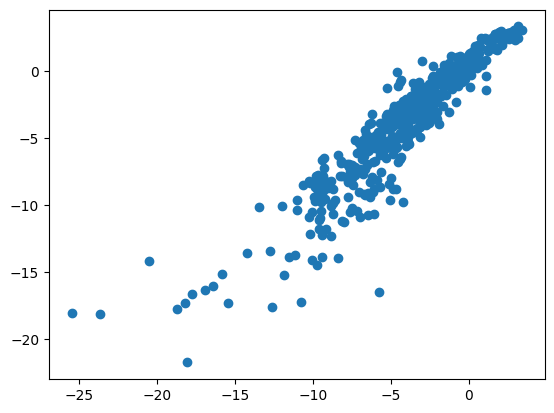

In [4]:
plt.scatter(free_solv_db['Expt_dG'], free_solv_db['Calc_GAFF_dG'])
plt.show()

In [5]:
import rdkit
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator, Draw
from rdkit.Chem.Draw import IPythonConsole

print(rdkit.__version__)
%pylab inline


2025.09.3
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [6]:
for row in free_solv_db.itertuples(index=False):
    mol = Chem.MolFromSmiles(row.SMILES)
    if mol is None:
        print("Error in SMILES string:", row.SMILES)

In [7]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

In [8]:
free_solv_db['morgan_fp'] = free_solv_db['SMILES'].apply(lambda x: mfpgen.GetFingerprint(Chem.MolFromSmiles(x)))

In [9]:
free_solv_db.head()

,Compound_ID,SMILES,IUPAC_Name,Expt_dG,Expt_uncertainty,Calc_GAFF_dG,Calc_uncertainty,morgan_fp
0,mobley_1017962,CCCCCC(=O)OC,methyl hexanoate,-2.49,0.6,-3.30,0.03,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
1,mobley_1019269,CCCCO,butan-1-ol,-4.72,0.6,-3.23,0.03,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,mobley_1034539,c1cc(c(cc1c2cc(c(c(c2Cl)Cl)Cl)Cl)Cl)Cl,"1,2,3,4-tetrachloro-5-(3,4-dichlorophenyl)ben...",-3.04,0.1,-1.08,0.04,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,mobley_1036761,C1CCC(CC1)N,cyclohexanamine,-4.59,0.6,-3.95,0.03,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,mobley_1046331,c1ccc(cc1)OC=O,phenyl formate,-3.82,0.6,-5.44,0.03,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [10]:
model = nn.Sequential(
    bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=2048, out_features=100),
    nn.ReLU(),
    bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=100, out_features=1),
)

In [11]:
mse_loss = nn.MSELoss()
kl_loss = bnn.BKLLoss(reduction='mean', last_layer_only=False)
kl_weight = 0.01

optimizer = optim.Adam(model.parameters(), lr=0.01)

In [20]:
x = torch.stack([torch.tensor(fp, dtype=torch.float32) for fp in free_solv_db['morgan_fp'].values])
y = torch.tensor(free_solv_db['Expt_dG'].values).unsqueeze(1).float()

x.dtype

torch.float32

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [27]:
kl_weight = 0.1

In [28]:
for step in range(3000):
    pre = model(x_train)
    mse = mse_loss(pre, y_train)
    kl = kl_loss(model)
    cost = mse + kl_weight*kl
    
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()
print(f"Step {step}: MSE={mse.item():.4f}, KL={kl.item():.4f}, Cost={cost.item():.4f}")

Step 2999: MSE=0.0058, KL=0.1128, Cost=0.0171


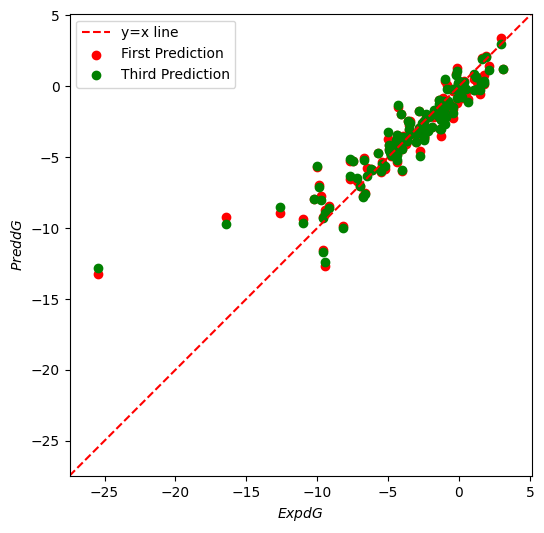

In [59]:
fig, ax = plt.subplots(figsize=(6,6))
ax.axline((0, 0), slope=1, color='r', linestyle='--', label='y=x line')
ax.set_aspect("equal", adjustable="box")


plt.xlabel(r'$Exp dG$')
plt.ylabel(r'$Pred dG$')


y_predict = model(x_test)
plt.scatter(y_test.data.numpy(), y_predict.data.numpy(), color='red', label='First Prediction')


y_predict = model(x_test)
#plt.scatter(y_test.data.numpy(), y_predict.data.numpy(), color='blue', label='Second Prediction')

y_predict = model(x_test)
plt.scatter(y_test.data.numpy(), y_predict.data.numpy(), color='green', label='Third Prediction')

min_val = y_test.data.numpy().min()
max_val = y_test.data.numpy().max()

ax.set_xlim(min_val-2, max_val+2)
ax.set_ylim(min_val-2, max_val+2)

plt.legend()

plt.show()
